Measuring BFS:
BFS Traversal:


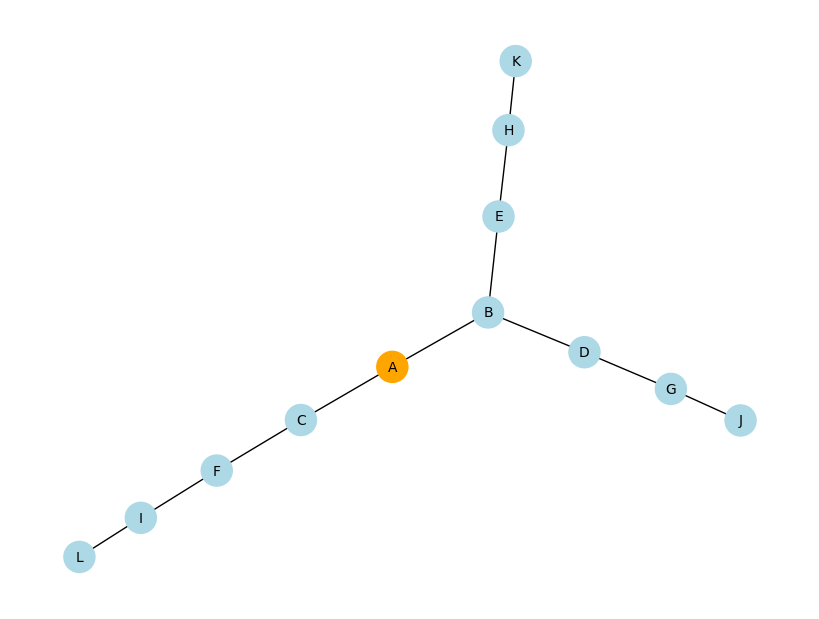

A 

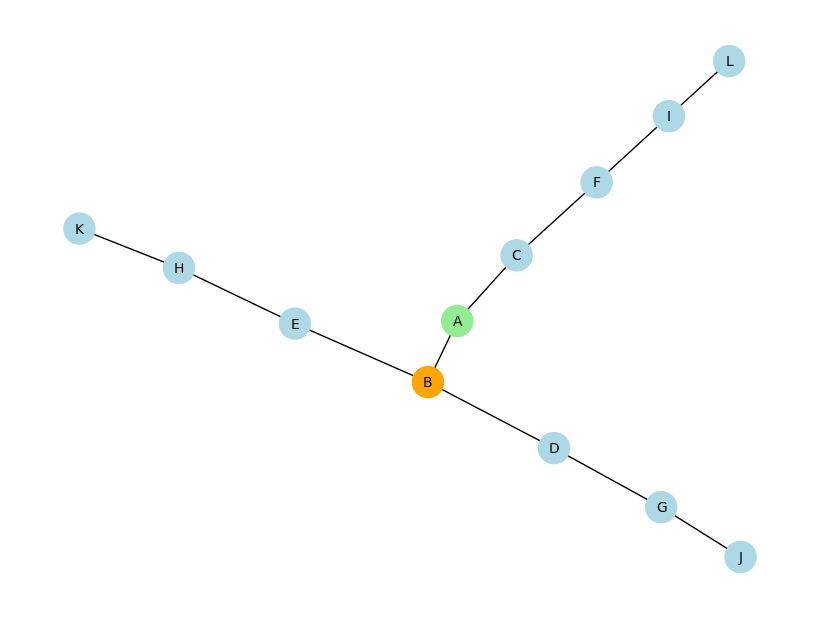

B 

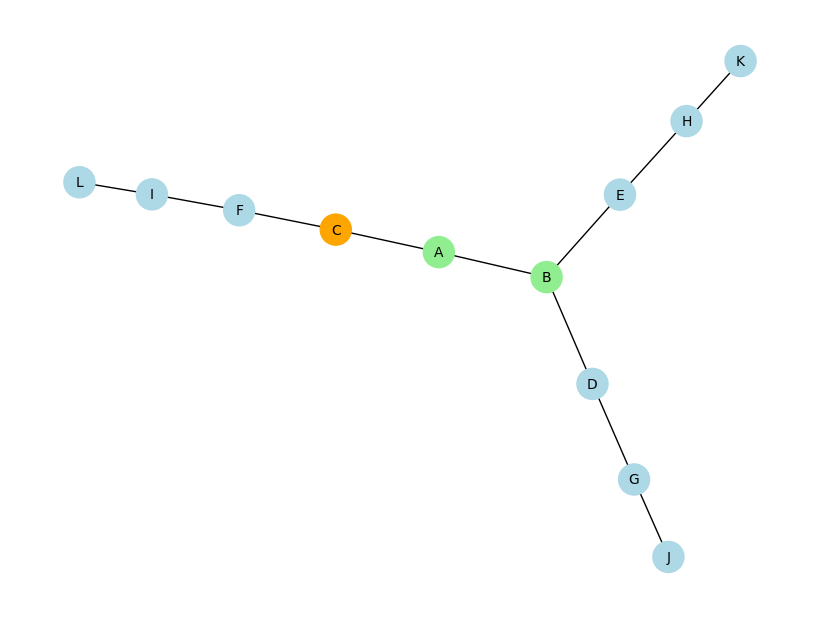

C 

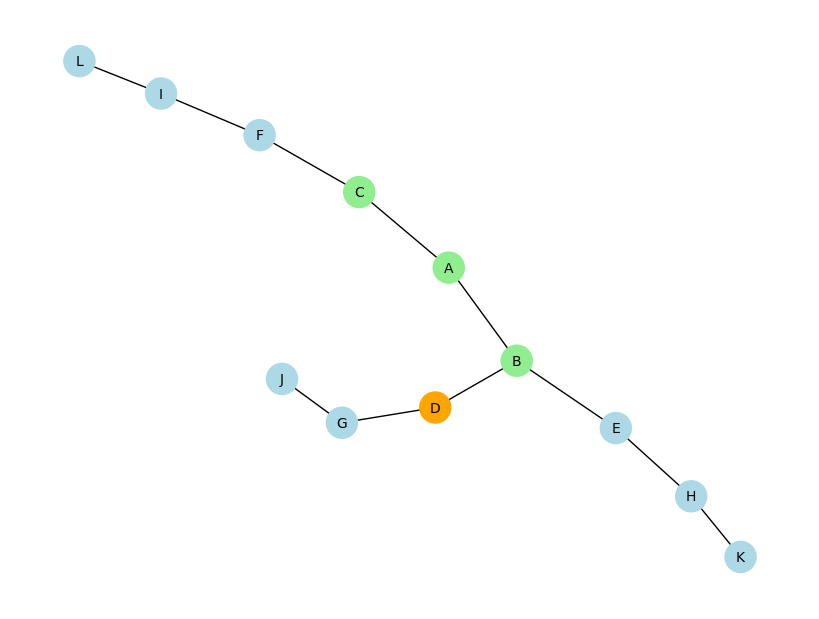

D 

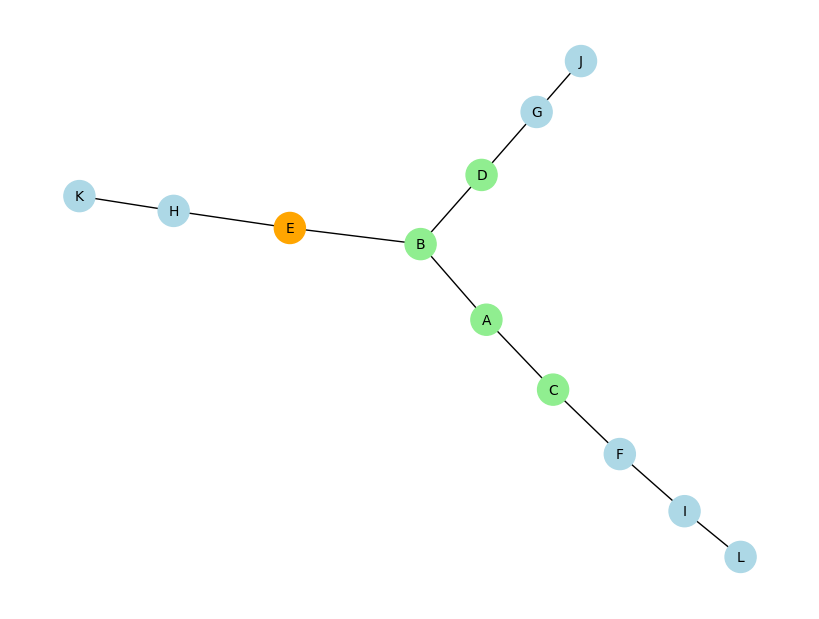

E 

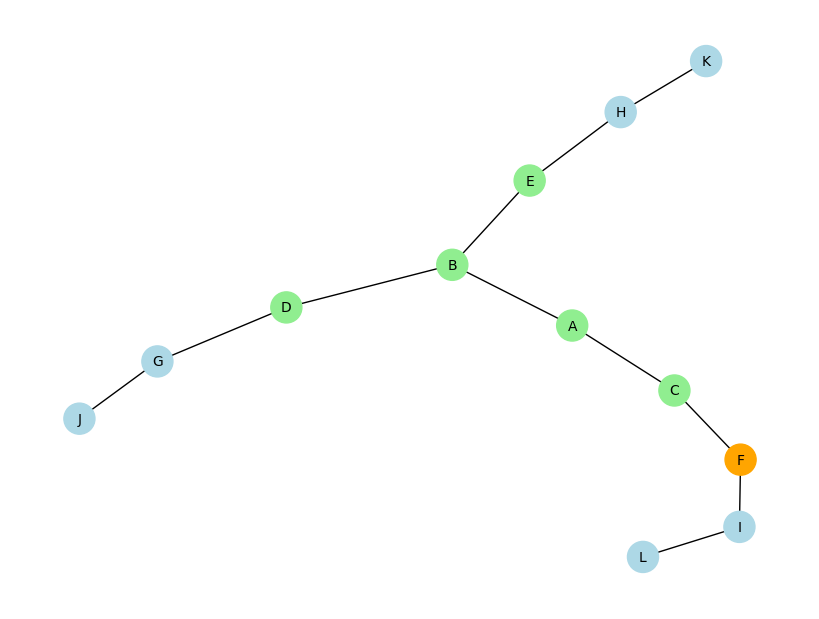

F 

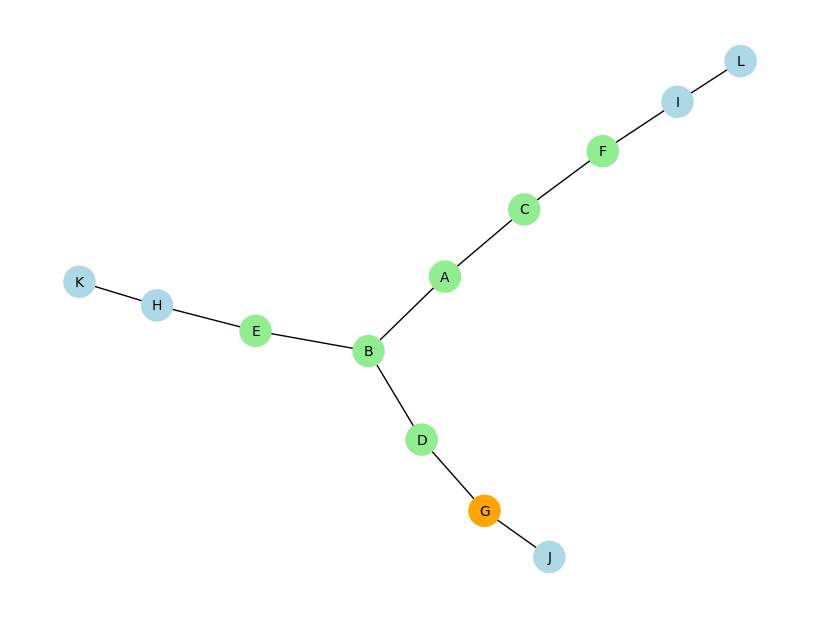

G 

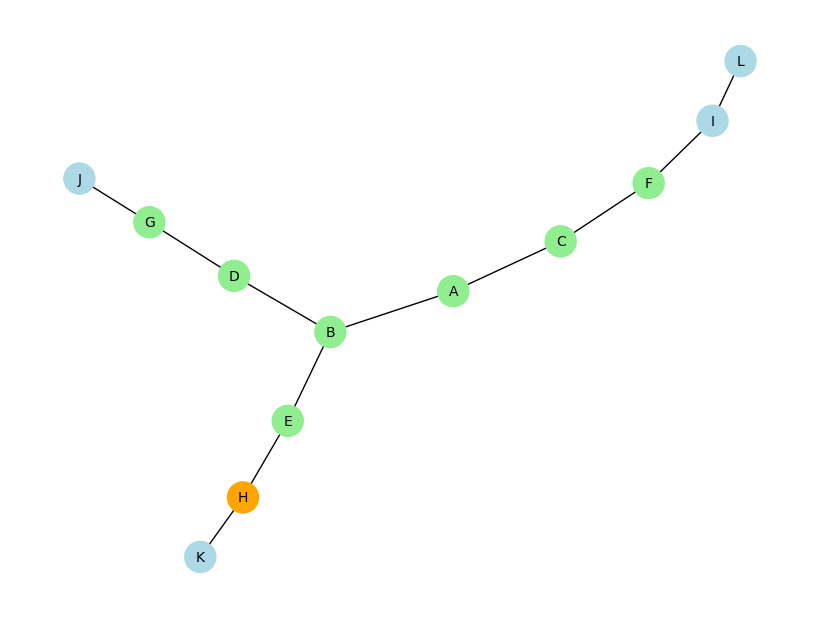

H 

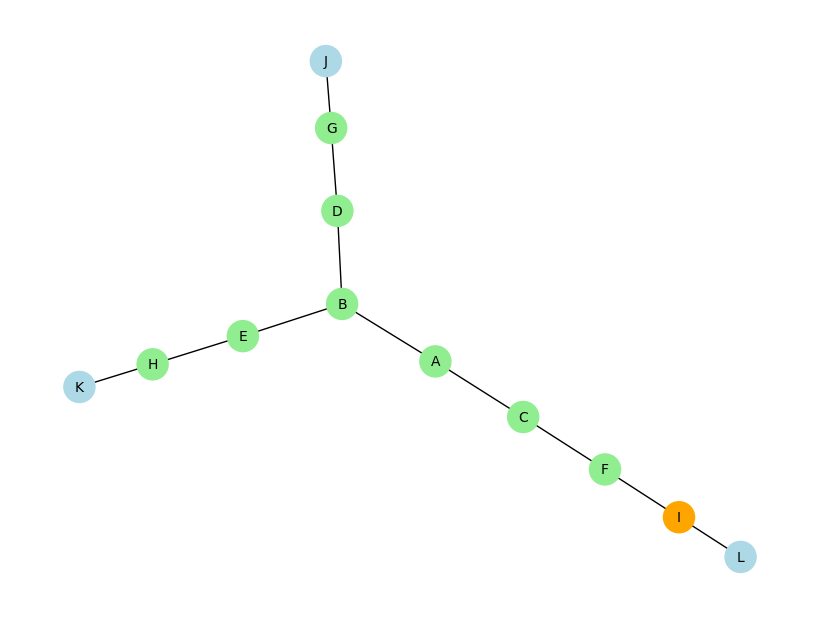

I 

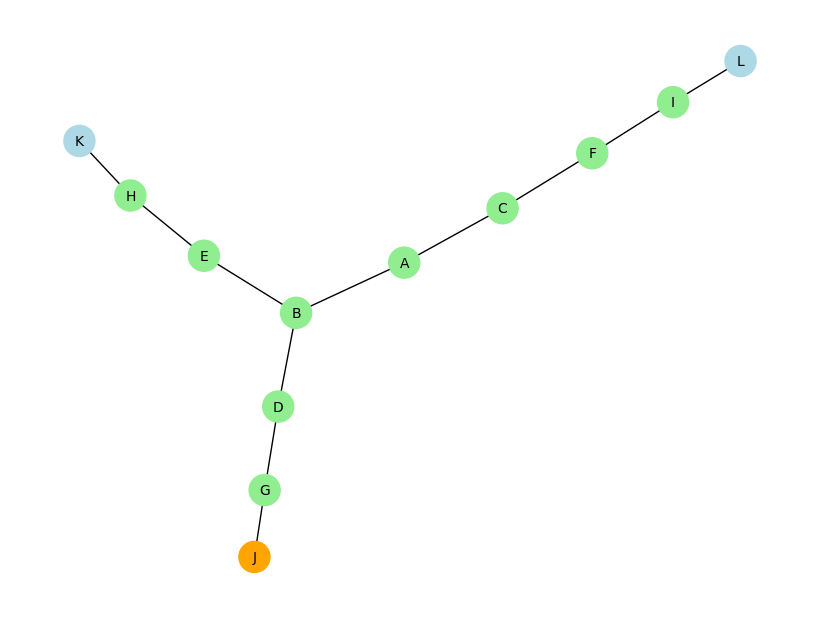

J 

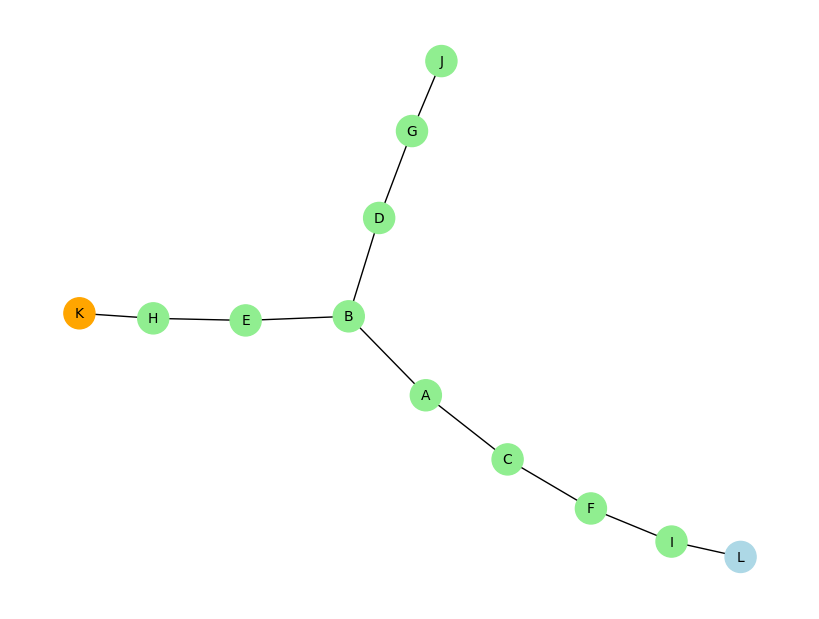

K 

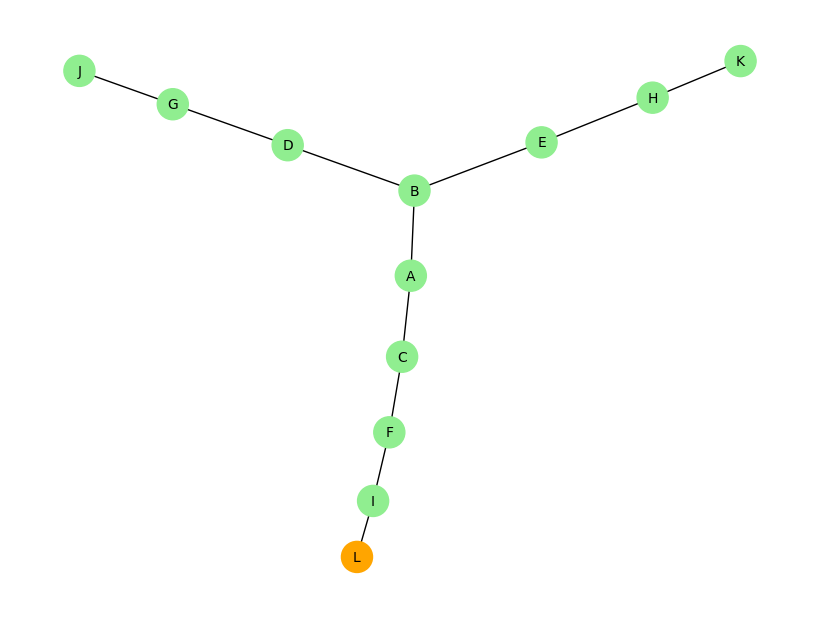

L 
BFS Execution Time: 12.123372 seconds
BFS Memory Usage: 6305.29 KB

Measuring DFS:


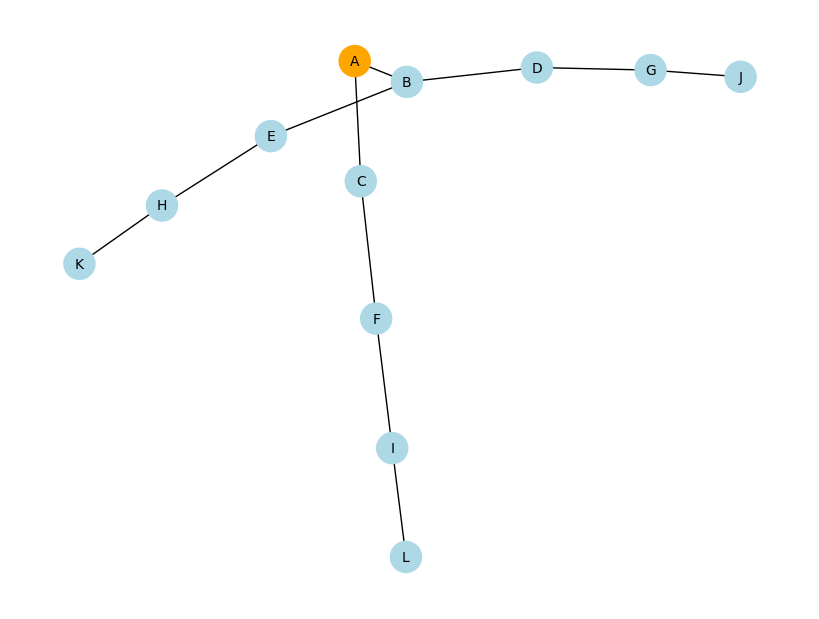

A 

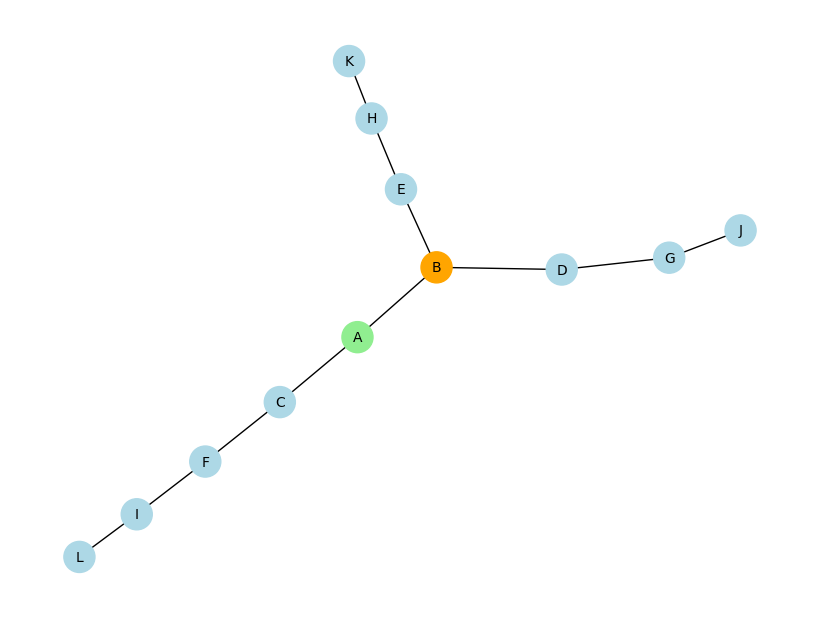

B 

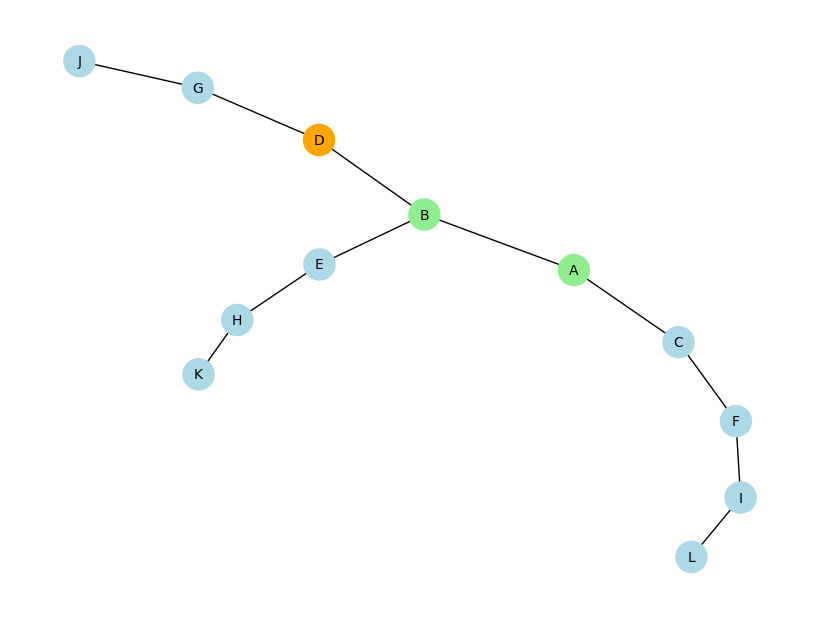

D 

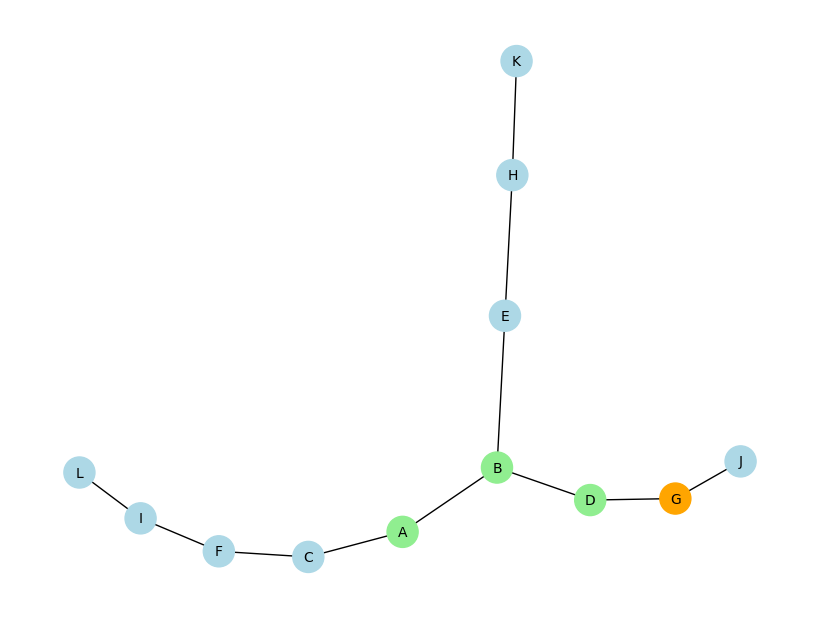

G 

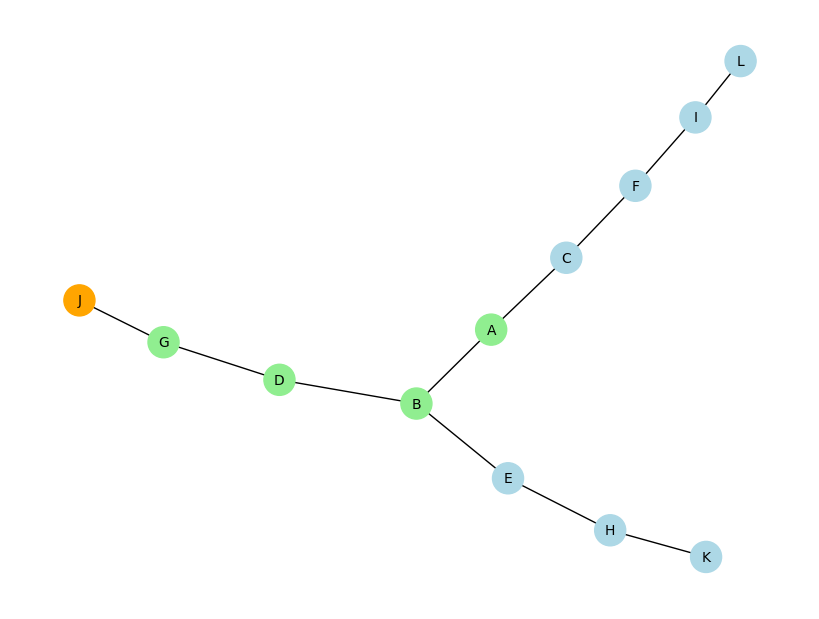

J 

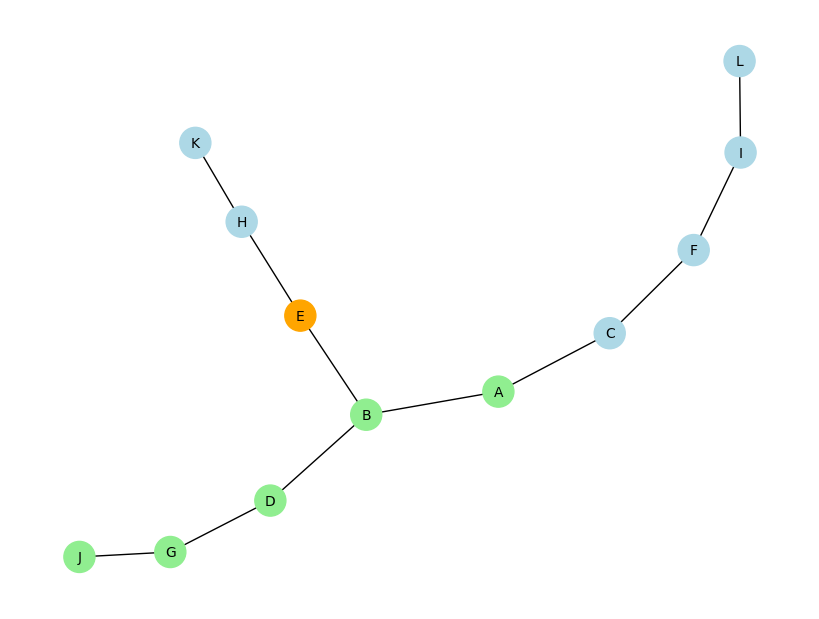

E 

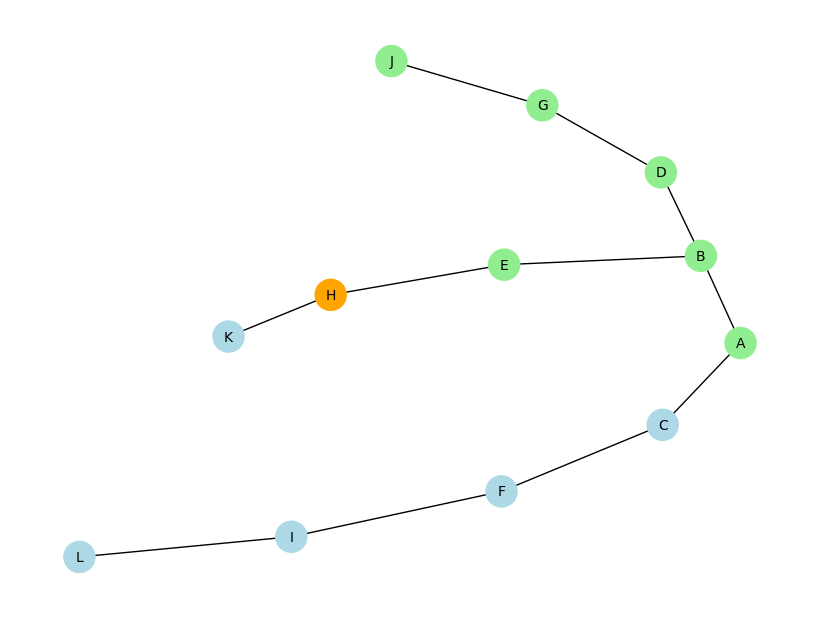

H 

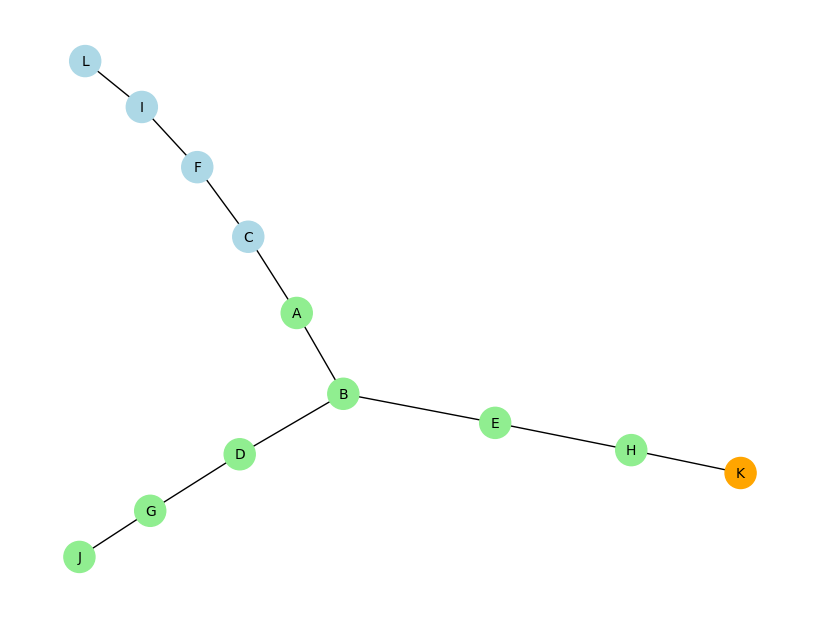

K 

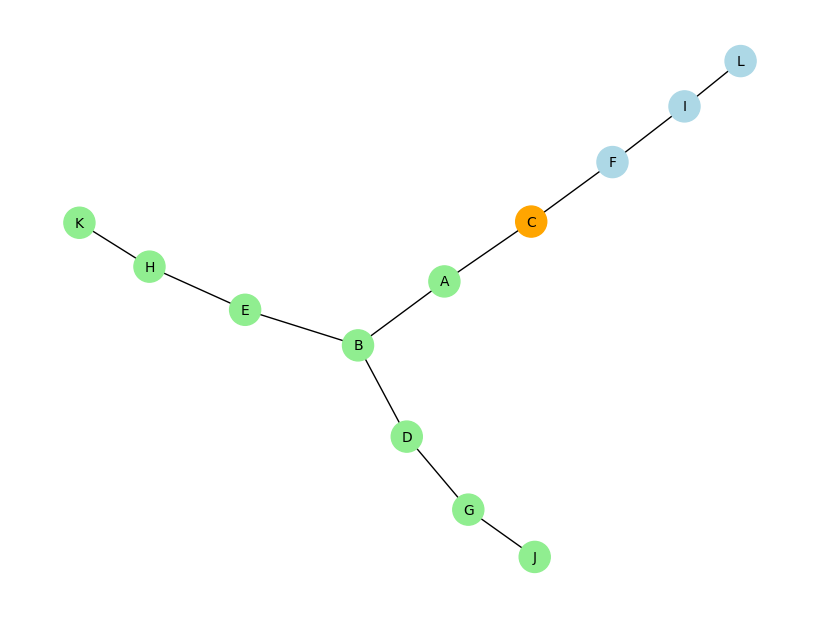

C 

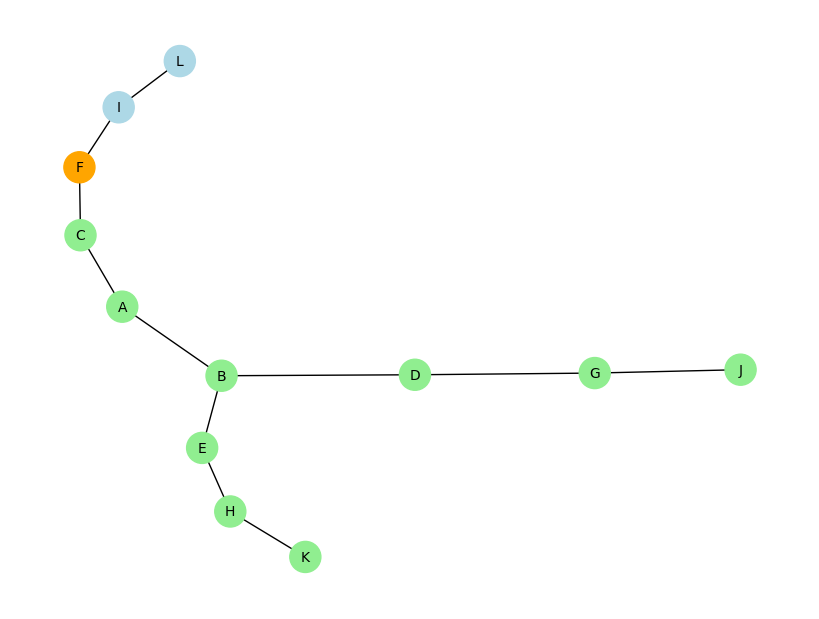

F 

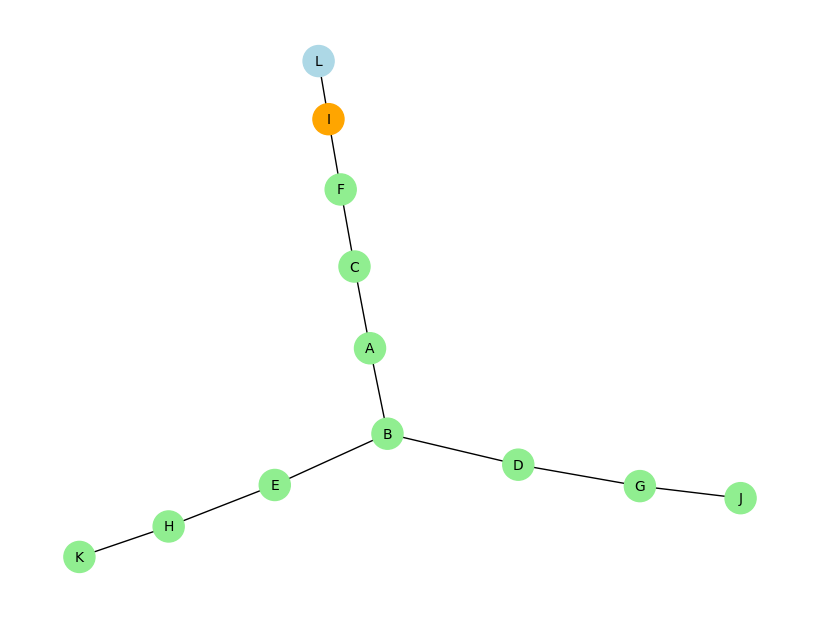

I 

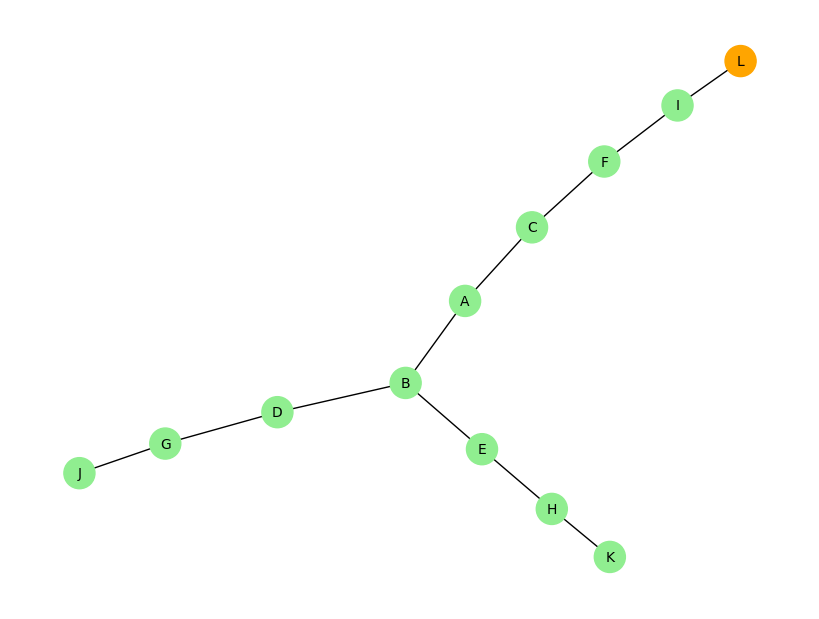

L DFS Execution Time: 5.262521 seconds
DFS Memory Usage: 4412.68 KB


In [1]:
# Importing necessary libraries
import matplotlib.pyplot as plt  # For plotting the graph
import networkx as nx  # For creating and manipulating the graph structure
from collections import deque  # For BFS queue implementation (FIFO)
from time import time  # For measuring execution time
import tracemalloc  # For measuring memory usage

# Function to draw the graph with highlighted nodes for BFS/DFS traversal
def draw_graph(graph, visited=None, current=None):
    # Create a graph object using NetworkX
    G = nx.Graph()
    # Adding edges to the graph based on the adjacency list
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    # Set the layout for node placement in the graph
    pos = nx.spring_layout(G)  # The spring layout algorithm positions nodes in a visually pleasing way

    # Create a figure for plotting the graph
    plt.figure(figsize=(8, 6))

    # Set the color of each node based on its state (visited or current node)
    node_colors = []
    for node in G.nodes():
        if visited and node in visited:  # If the node has been visited, color it light green
            node_colors.append('lightgreen')
        elif current == node:  # If the node is the current node in BFS/DFS, color it orange
            node_colors.append('orange')
        else:  # Default color for unvisited nodes
            node_colors.append('lightblue')

    # Draw the graph using NetworkX's draw function with specified node colors and sizes
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=10, font_color='black')
    # Show the graph
    plt.show()

# BFS function to traverse the graph
def bfs(graph, start):
    visited = set()  # Set to keep track of visited nodes
    queue = deque([start])  # Queue for BFS (using deque for efficient popping from left)

    print("BFS Traversal:")
    while queue:  # While the queue is not empty
        current = queue.popleft()  # Dequeue the first node (FIFO behavior)
        draw_graph(graph, visited, current)  # Draw the graph with the current node highlighted

        if current not in visited:  # If the node has not been visited yet
            print(current, end=" ")  # Print the current node
            visited.add(current)  # Mark the node as visited
            # Add unvisited neighbors to the queue
            queue.extend(neighbor for neighbor in graph[current] if neighbor not in visited)

    print()  # Newline after BFS traversal

# DFS function to traverse the graph
def dfs(graph, start, visited=None):
    if visited is None:
        visited = set()  # Initialize the visited set if not passed

    draw_graph(graph, visited, start)  # Draw the graph with the current node highlighted

    if start not in visited:  # If the node has not been visited
        print(start, end=" ")  # Print the current node
        visited.add(start)  # Mark the node as visited
        # Recursively visit unvisited neighbors
        for neighbor in graph[start]:
            if neighbor not in visited:
                dfs(graph, neighbor, visited)

# Main code execution starts here
if __name__ == "__main__":
    # Define the graph using an adjacency list representation
    graph = {
      'A': ['B', 'C'],
      'B': ['A', 'D', 'E'],
      'C': ['A', 'F'],
      'D': ['B', 'G'],
      'E': ['B', 'H'],
      'F': ['C', 'I'],
      'G': ['D', 'J'],
      'H': ['E', 'K'],
      'I': ['F', 'L'],
      'J': ['G'],
      'K': ['H'],
      'L': ['I']
    }

    # Measuring BFS execution time and memory usage
    print("Measuring BFS:")
    tracemalloc.start()  # Start tracking memory usage
    start_time = time()  # Record the start time
    bfs(graph, 'A')  # Call BFS function starting from node 'A'
    bfs_time = time() - start_time  # Calculate the elapsed time for BFS
    bfs_memory = tracemalloc.get_traced_memory()[1]  # Get the peak memory usage during BFS
    tracemalloc.stop()  # Stop tracking memory usage
    # Print the results for BFS
    print(f"BFS Execution Time: {bfs_time:.6f} seconds")
    print(f"BFS Memory Usage: {bfs_memory / 1024:.2f} KB")

    # Measuring DFS execution time and memory usage
    print("\nMeasuring DFS:")
    tracemalloc.start()  # Start tracking memory usage
    start_time = time()  # Record the start time
    dfs(graph, 'A')  # Call DFS function starting from node 'A'
    dfs_time = time() - start_time  # Calculate the elapsed time for DFS
    dfs_memory = tracemalloc.get_traced_memory()[1]  # Get the peak memory usage during DFS
    tracemalloc.stop()  # Stop tracking memory usage
    # Print the results for DFS
    print(f"DFS Execution Time: {dfs_time:.6f} seconds")
    print(f"DFS Memory Usage: {dfs_memory / 1024:.2f} KB")